# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

THE ABOVE LINK IS JUST FOR REFERENCE - PLEASE DO NOT USE THE DATASET PROVIDED IN THE ABOVE WEBPAGE FOR SOLVING THE ASSIGNMENT.

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
# Import warnings
import warnings

warnings.filterwarnings("ignore")

In [2]:
# Import the libraries you will be using for analysis
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")

In [3]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 1.26.4
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [5]:
# Try loading one file

# df = pd.read_parquet('2023-1.parquet')
# df.info()

trip_records_dir = Path("data/trip_records")
sample_file = sorted(trip_records_dir.glob("2023-*.parquet"), key=lambda p: int(p.stem.split("-")[1]))[0]

df = pd.read_parquet(sample_file)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [6]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

trip_records_dir = Path("data/trip_records")
sample_fraction = 0.05
random_state = 42

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [7]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
# os.chdir('/content/Assignments/EDA/data_NYC_Taxi/trip_records')  # colab path; using local folder instead
data_dir = Path("data/trip_records")

# Create a list of all the twelve files to read
file_list = sorted(data_dir.glob("2023-*.parquet"), key=lambda p: int(p.stem.split("-")[1]))

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = file_name

        # Reading the current file
        month_df = pd.read_parquet(file_path)
        month_df["tpep_pickup_datetime"] = pd.to_datetime(month_df["tpep_pickup_datetime"], errors="coerce")
        month_df = month_df.dropna(subset=["tpep_pickup_datetime"]).copy()
        month_df["pickup_date"] = month_df["tpep_pickup_datetime"].dt.date
        month_df["pickup_hour"] = month_df["tpep_pickup_datetime"].dt.hour

        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date
        for pickup_date, date_df in month_df.groupby("pickup_date"):

            # Iterate through each hour of the selected date
            for hour, hour_data in date_df.groupby("pickup_hour"):

                # Sample 5% of the hourly data randomly
                sample = hour_data.sample(frac=sample_fraction, random_state=random_state)

                # add data of this hour to the dataframe
                sampled_data = pd.concat([sampled_data, sample])

        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df, sampled_data.drop(columns=["pickup_date"])], ignore_index=True)  # we initialised this empty DF earlier

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

df.shape

(1896400, 21)

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [8]:
# Store the df in csv/parquet
# df.to_parquet('')

sampled_parquet_path = Path("data/trip_records_2023_sampled.parquet")
sampled_csv_path = Path("data/trip_records_2023_sampled.csv")

df.to_parquet(sampled_parquet_path, index=False)
df.to_csv(sampled_csv_path, index=False)

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [9]:
# Load the new data file
df = pd.read_parquet("data/trip_records_2023_sampled.parquet")
df.shape

(1896400, 21)

In [10]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,Airport_fee
0,2,2022-12-31 23:51:30,2022-12-31 23:56:06,1.0,0.86,1.0,N,141,140,1,...,1.0,0.5,2.00,0.0,1.0,13.50,2.5,0.00,23,NaN
1,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,0,NaN
2,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,0,NaN
3,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,0,NaN
4,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,0,NaN


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 21 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [15]:
# Fix the index and drop any columns that are not needed
df = df.reset_index(drop=True)
df.columns = [c.strip() for c in df.columns]

# Drop Unnamed:* columns (spurious index columns from parquet/csv round-trips)
drop_cols = [c for c in df.columns if c.lower().startswith("unnamed")]

# Drop store_and_fwd_flag — not used in any analysis task
if "store_and_fwd_flag" in df.columns:
    drop_cols.append("store_and_fwd_flag")

# Drop pickup_hour left over from the sampling step; it will be re-derived later
if "pickup_hour" in df.columns:
    drop_cols.append("pickup_hour")

before = df.shape[1]
if drop_cols:
    df = df.drop(columns=drop_cols)
after = df.shape[1]

print(f"Columns before: {before}, after: {after}, dropped: {drop_cols}")
df.head()

Columns before: 20, after: 18, dropped: ['store_and_fwd_flag', 'pickup_hour']


,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2022-12-31 23:51:30,2022-12-31 23:56:06,1.0,0.86,1.0,141,140,1,6.5,1.0,0.5,2.00,0.0,1.0,13.50,2.5,0.00
1,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,138,256,2,32.4,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25
2,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,161,237,1,7.9,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00
3,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,237,141,2,11.4,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00
4,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,143,142,2,6.5,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [16]:
# Combine the two airport fee columns
airport_cols = [c for c in df.columns if c.lower() == "airport_fee"]

if len(airport_cols) > 1:
    primary_col = airport_cols[0]
    for col in airport_cols[1:]:
        df[primary_col] = df[primary_col].fillna(0) + df[col].fillna(0)
    df = df.drop(columns=airport_cols[1:])
    if primary_col != "airport_fee":
        df = df.rename(columns={primary_col: "airport_fee"})
elif len(airport_cols) == 1 and airport_cols[0] != "airport_fee":
    df = df.rename(columns={airport_cols[0]: "airport_fee"})

df.columns = [c.lower() for c in df.columns]
[c for c in df.columns if "airport" in c]

['airport_fee']

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [17]:
# check where values of fare amount are negative
neg_fare_rows = df[df["fare_amount"] < 0]
neg_fare_rows[["fare_amount", "ratecodeid", "payment_type", "trip_distance"]].head()

,fare_amount,ratecodeid,payment_type,trip_distance


Did you notice something different in the `RatecodeID` column for above records?

In [18]:
# Analyse RatecodeID for the negative fare amounts
df.loc[df["fare_amount"] < 0, "ratecodeid"].value_counts(dropna=False)

Series([], Name: count, dtype: int64)

In [19]:
# Find which columns have negative values
numeric_cols = df.select_dtypes(include=[np.number]).columns
negative_counts = (df[numeric_cols] < 0).sum()
negative_counts[negative_counts > 0].sort_values(ascending=False)

improvement_surcharge    78
total_amount             78
mta_tax                  73
congestion_surcharge     56
airport_fee              15
extra                     3
dtype: int64

In [20]:
# fix these negative values
monetary_cols = [
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount",
    "congestion_surcharge",
    "airport_fee",
]

for col in monetary_cols:
    if col in df.columns:
        df[col] = df[col].abs()

if "trip_distance" in df.columns:
    df["trip_distance"] = df["trip_distance"].abs()

df[monetary_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
fare_amount,1896400.0,19.919350,105.537084,0.0,9.30,13.50,21.90,143163.45
extra,1896400.0,1.588022,1.829196,0.0,0.00,1.00,2.50,20.80
mta_tax,1896400.0,0.495318,0.048459,0.0,0.50,0.50,0.50,4.00
tip_amount,1896400.0,3.547011,4.054882,0.0,1.00,2.85,4.42,223.08
tolls_amount,1896400.0,0.596534,2.187878,0.0,0.00,0.00,0.00,143.00
improvement_surcharge,1896400.0,0.999053,0.028357,0.0,1.00,1.00,1.00,1.00
total_amount,1896400.0,28.982159,106.416150,0.0,15.96,21.00,30.94,143167.45
congestion_surcharge,1831526.0,2.307677,0.666197,0.0,2.50,2.50,2.50,2.50
airport_fee,1896400.0,0.138035,0.457582,0.0,0.00,0.00,0.00,1.75


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [21]:
# Find the proportion of missing values in each column
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0]

congestion_surcharge    3.420903
passenger_count         3.420903
ratecodeid              3.420903
dtype: float64

**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [22]:
# Display the rows with null values
df[df["passenger_count"].isna()].head()

# Impute NaN values in 'passenger_count'
passenger_fill = int(df.loc[df["passenger_count"] > 0, "passenger_count"].median())
df["passenger_count"] = df["passenger_count"].fillna(passenger_fill)
df.loc[df["passenger_count"] <= 0, "passenger_count"] = passenger_fill
df["passenger_count"] = df["passenger_count"].round().astype(int)

df["passenger_count"].value_counts().sort_index().head()

passenger_count
1    1471779
2     277298
3      69034
4      38537
5      23871
Name: count, dtype: int64

Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [23]:
# Fix missing values in 'RatecodeID'
ratecode_fill = int(df["ratecodeid"].dropna().mode().iloc[0])
df["ratecodeid"] = df["ratecodeid"].fillna(ratecode_fill).round().astype(int)
df["ratecodeid"].value_counts(dropna=False).sort_index()

ratecodeid
1     1794133
2       71670
3        6124
4        3723
5       10275
6           3
99      10472
Name: count, dtype: int64

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [24]:
# handle null values in congestion_surcharge
df["congestion_surcharge"] = df.groupby("payment_type")["congestion_surcharge"].transform(lambda s: s.fillna(s.median()))
df["congestion_surcharge"] = df["congestion_surcharge"].fillna(df["congestion_surcharge"].median())
df["congestion_surcharge"].describe()

count    1.896400e+06
mean     2.314256e+00
std      6.556359e-01
min      0.000000e+00
25%      2.500000e+00
50%      2.500000e+00
75%      2.500000e+00
max      2.500000e+00
Name: congestion_surcharge, dtype: float64

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [25]:
# Handle any remaining missing values
for col in ["vendorid", "payment_type", "store_and_fwd_flag"]:
    if col in df.columns and df[col].isna().any():
        df[col] = df[col].fillna(df[col].mode().iloc[0])

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

df.isna().sum().sort_values(ascending=False).head(10)

vendorid                 0
tpep_pickup_datetime     0
congestion_surcharge     0
total_amount             0
improvement_surcharge    0
tolls_amount             0
tip_amount               0
mta_tax                  0
extra                    0
fare_amount              0
dtype: int64

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [26]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"], errors="coerce")
df["trip_duration"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60

df[["trip_distance", "fare_amount", "tip_amount", "total_amount", "trip_duration"]].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
trip_distance,1896400.0,3.858293,129.408540,0.0,0.0,0.460000,1.790000,15.290000,20.22,126360.460000
fare_amount,1896400.0,19.919350,105.537084,0.0,4.4,5.800000,13.500000,70.000000,77.20,143163.450000
tip_amount,1896400.0,3.547011,4.054882,0.0,0.0,0.000000,2.850000,12.000000,17.68,223.080000
total_amount,1896400.0,28.982159,106.416150,0.0,8.7,11.500000,21.000000,82.690000,104.16,143167.450000
trip_duration,1896400.0,17.433146,41.066636,-54.3,0.9,3.483333,12.666667,43.016667,67.60,6266.383333


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [27]:
# remove passenger_count > 6
df = df[df["passenger_count"] <= 6].copy()
df.shape

(1896379, 19)

In [28]:
# Continue with outlier handling
mask_near_zero_dist_high_fare = (df["trip_distance"] <= 0.1) & (df["fare_amount"] > 300)
mask_zero_dist_zero_fare_diff_zone = (df["trip_distance"] == 0) & (df["fare_amount"] == 0) & (df["pulocationid"] != df["dolocationid"])
mask_very_long_distance = df["trip_distance"] > 250

outlier_mask = mask_near_zero_dist_high_fare | mask_zero_dist_zero_fare_diff_zone | mask_very_long_distance
df = df.loc[~outlier_mask].copy()

valid_payment_mode = int(df.loc[df["payment_type"] > 0, "payment_type"].mode().iloc[0])
df.loc[df["payment_type"] == 0, "payment_type"] = valid_payment_mode
df["payment_type"] = df["payment_type"].astype(int)

df = df[(df["trip_duration"] > 0) & (df["trip_duration"] <= 240)].copy()
df.shape

(1893812, 19)

In [29]:
# Do any columns need standardising?
int_cols = [
    "vendorid",
    "passenger_count",
    "ratecodeid",
    "pulocationid",
    "dolocationid",
    "payment_type",
]

for col in int_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].fillna(df[col].mode().iloc[0]).round().astype(int)

df.dtypes

vendorid                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                   int32
trip_distance                   float64
ratecodeid                        int32
pulocationid                      int32
dolocationid                      int32
payment_type                      int32
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
trip_duration                   float64
dtype: object

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [30]:
df.columns.tolist()

['vendorid',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'ratecodeid',
 'pulocationid',
 'dolocationid',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'trip_duration']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

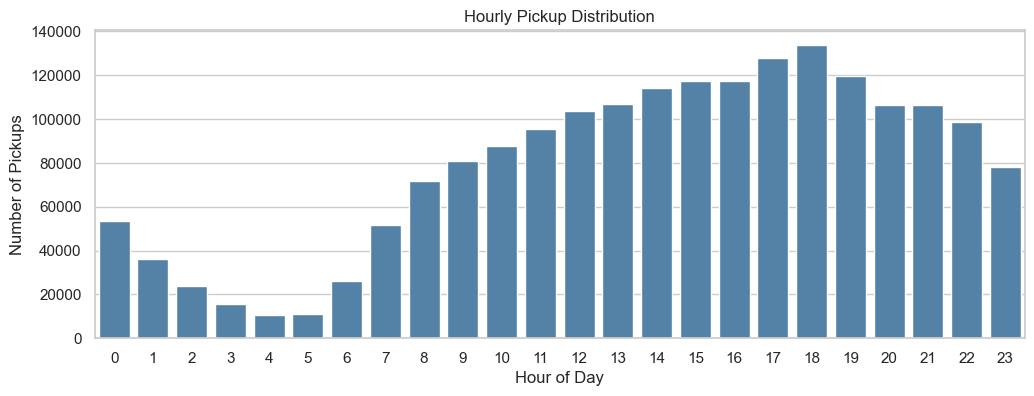

pickup_hour
18    133781
17    127686
19    119522
16    117315
15    117230
dtype: int64

In [31]:
# Find and show the hourly trends in taxi pickups
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
hourly_pickups = df.groupby("pickup_hour").size().reindex(range(24), fill_value=0)

plt.figure(figsize=(12, 4))
sns.barplot(x=hourly_pickups.index, y=hourly_pickups.values, color="steelblue")
plt.title("Hourly Pickup Distribution")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Pickups")
plt.show()

hourly_pickups.sort_values(ascending=False).head()

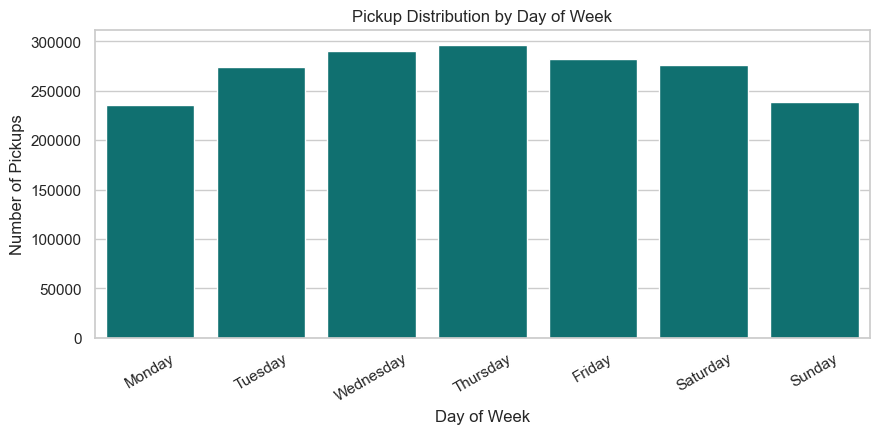

pickup_day
Monday       236016
Tuesday      273937
Wednesday    290137
Thursday     296917
Friday       281792
Saturday     275799
Sunday       239214
dtype: int64

In [32]:
# Find and show the daily trends in taxi pickups (days of the week)
df["pickup_day"] = df["tpep_pickup_datetime"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily_pickups = df.groupby("pickup_day").size().reindex(day_order)

plt.figure(figsize=(10, 4))
sns.barplot(x=daily_pickups.index, y=daily_pickups.values, color="teal")
plt.title("Pickup Distribution by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Pickups")
plt.xticks(rotation=30)
plt.show()

daily_pickups

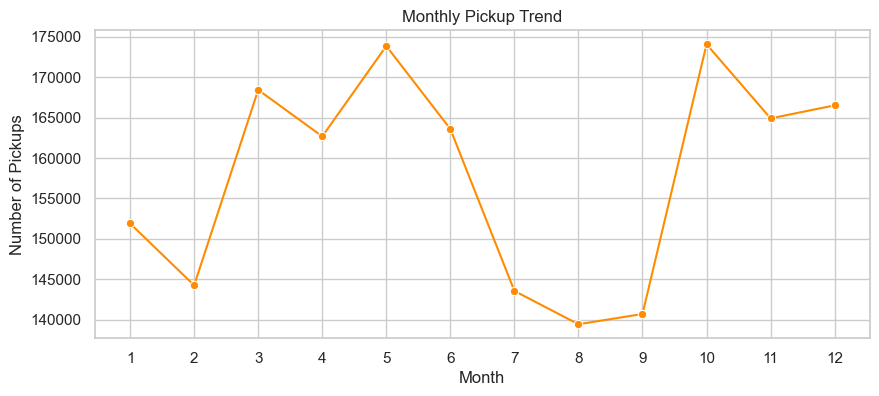

pickup_month
1     151894
2     144245
3     168423
4     162669
5     173851
6     163581
7     143547
8     139428
9     140697
10    174070
11    164898
12    166509
dtype: int64

In [70]:
# Show the monthly trends in pickups
df["pickup_month"] = df["tpep_pickup_datetime"].dt.month
monthly_pickups = df.groupby("pickup_month").size().reindex(range(1, 13), fill_value=0)

plt.figure(figsize=(10, 4))
sns.lineplot(x=monthly_pickups.index, y=monthly_pickups.values, marker="o", color="darkorange")
plt.title("Monthly Pickup Trend")
plt.xlabel("Month")
plt.ylabel("Number of Pickups")
plt.xticks(range(1, 13))
plt.show()

monthly_pickups

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [33]:
# Analyse the above parameters
analysis_cols = ["fare_amount", "tip_amount", "total_amount", "trip_distance"]
summary_financial = pd.DataFrame({
    "zero_count": [(df[c] == 0).sum() for c in analysis_cols],
    "negative_count": [(df[c] < 0).sum() for c in analysis_cols],
    "min_value": [df[c].min() for c in analysis_cols],
    "max_value": [df[c].max() for c in analysis_cols],
}, index=analysis_cols)
summary_financial

,zero_count,negative_count,min_value,max_value
fare_amount,583,0,0.0,143163.45
tip_amount,434327,0,0.0,223.08
total_amount,262,0,0.0,143167.45
trip_distance,36969,0,0.0,204.10


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [34]:
# Create a df with non zero entries for the selected parameters.
df_nz = df[(df["fare_amount"] > 0) & (df["total_amount"] > 0) & (df["trip_distance"] > 0) & (df["tip_amount"] >= 0)].copy()
df_nz.shape

(1856518, 21)

**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

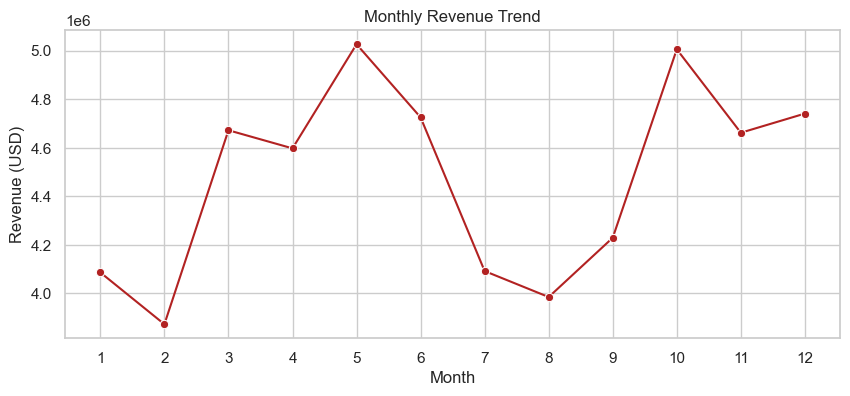

tpep_pickup_datetime
1     4086591.15
2     3873173.54
3     4672683.82
4     4598020.48
5     5027119.23
6     4725702.04
7     4092321.98
8     3985354.08
9     4229696.52
10    5006340.14
11    4662406.69
12    4741414.46
Name: total_amount, dtype: float64

In [35]:
# Group data by month and analyse monthly revenue
monthly_revenue = df_nz.groupby(df_nz["tpep_pickup_datetime"].dt.month)["total_amount"].sum().reindex(range(1, 13), fill_value=0)

plt.figure(figsize=(10, 4))
sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, marker="o", color="firebrick")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (USD)")
plt.xticks(range(1, 13))
plt.show()

monthly_revenue

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

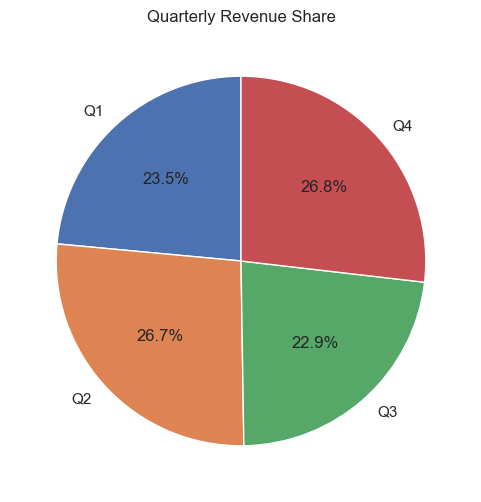

tpep_pickup_datetime
1    23.523752
2    26.723690
3    22.918405
4    26.834153
Name: total_amount, dtype: float64

In [36]:
# Calculate proportion of each quarter
quarterly_revenue = df_nz.groupby(df_nz["tpep_pickup_datetime"].dt.quarter)["total_amount"].sum().sort_index()
quarterly_share = (quarterly_revenue / quarterly_revenue.sum()) * 100

plt.figure(figsize=(6, 6))
plt.pie(quarterly_share.values, labels=[f"Q{q}" for q in quarterly_share.index], autopct="%1.1f%%", startangle=90)
plt.title("Quarterly Revenue Share")
plt.show()

quarterly_share

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

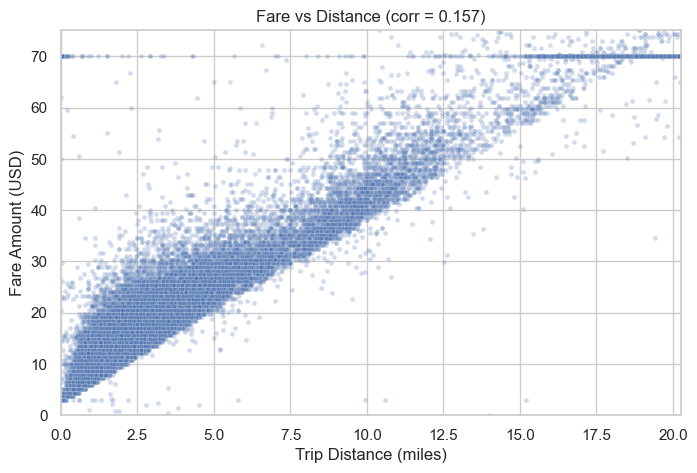

0.1573453952226794

In [37]:
# Show how trip fare is affected by distance
distance_fare_corr = df_nz[["trip_distance", "fare_amount"]].corr().iloc[0, 1]

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_nz.sample(min(50000, len(df_nz)), random_state=42),
    x="trip_distance",
    y="fare_amount",
    alpha=0.25,
    s=12,
)
plt.title(f"Fare vs Distance (corr = {distance_fare_corr:.3f})")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare Amount (USD)")
plt.xlim(0, df_nz["trip_distance"].quantile(0.99))
plt.ylim(0, df_nz["fare_amount"].quantile(0.99))
plt.show()

distance_fare_corr

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

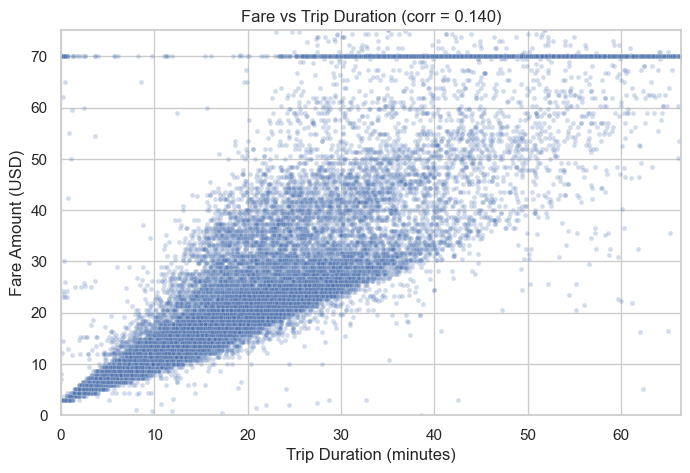

0.14005749612984436

In [38]:
# Show relationship between fare and trip duration
fare_duration_corr = df_nz[["fare_amount", "trip_duration"]].corr().iloc[0, 1]

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_nz.sample(min(50000, len(df_nz)), random_state=42),
    x="trip_duration",
    y="fare_amount",
    alpha=0.25,
    s=12,
)
plt.title(f"Fare vs Trip Duration (corr = {fare_duration_corr:.3f})")
plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Fare Amount (USD)")
plt.xlim(0, df_nz["trip_duration"].quantile(0.99))
plt.ylim(0, df_nz["fare_amount"].quantile(0.99))
plt.show()

fare_duration_corr

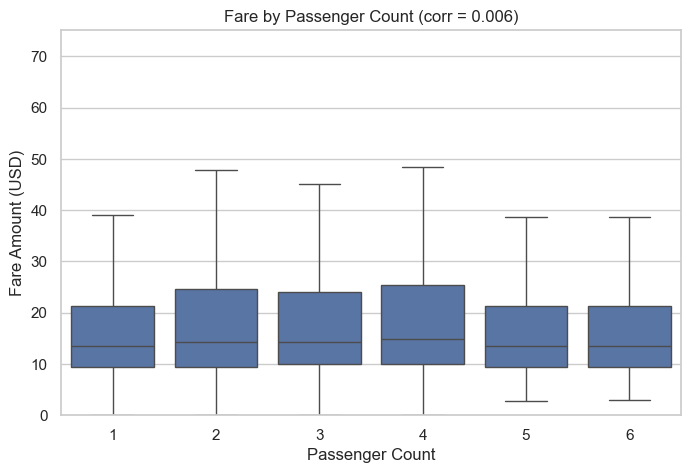

0.006329696749439137

In [39]:
# Show relationship between fare and number of passengers
fare_passenger_corr = df_nz[["fare_amount", "passenger_count"]].corr().iloc[0, 1]

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_nz, x="passenger_count", y="fare_amount", showfliers=False)
plt.title(f"Fare by Passenger Count (corr = {fare_passenger_corr:.3f})")
plt.xlabel("Passenger Count")
plt.ylabel("Fare Amount (USD)")
plt.ylim(0, df_nz["fare_amount"].quantile(0.99))
plt.show()

fare_passenger_corr

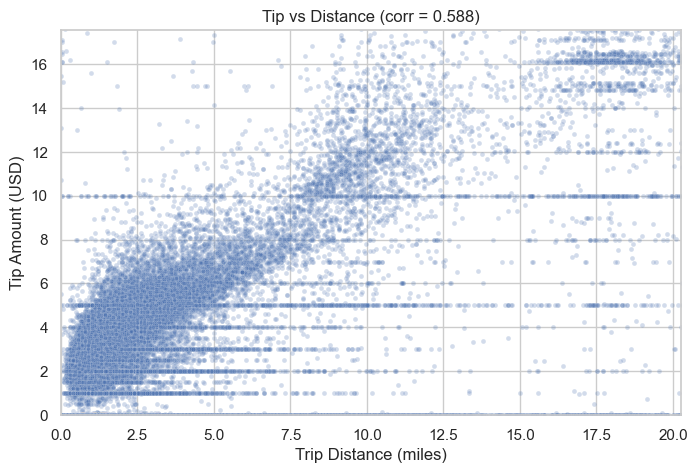

0.5875800502947258

In [40]:
# Show relationship between tip and trip distance
tip_distance_corr = df_nz[["tip_amount", "trip_distance"]].corr().iloc[0, 1]

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_nz.sample(min(50000, len(df_nz)), random_state=42),
    x="trip_distance",
    y="tip_amount",
    alpha=0.25,
    s=12,
)
plt.title(f"Tip vs Distance (corr = {tip_distance_corr:.3f})")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Tip Amount (USD)")
plt.xlim(0, df_nz["trip_distance"].quantile(0.99))
plt.ylim(0, df_nz["tip_amount"].quantile(0.99))
plt.show()

tip_distance_corr

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

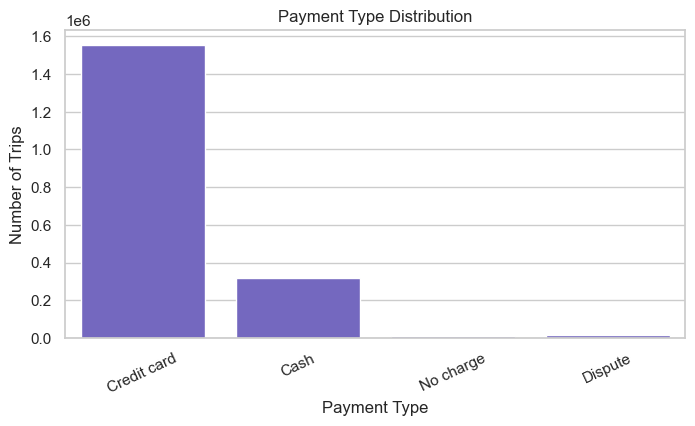

payment_type
1    82.15
2    16.65
3     0.47
4     0.72
Name: count, dtype: float64

In [41]:
# Analyse the distribution of different payment types (payment_type).
payment_map = {
    1: "Credit card",
    2: "Cash",
    3: "No charge",
    4: "Dispute",
    5: "Unknown",
    6: "Voided trip",
}

payment_dist = df["payment_type"].value_counts().sort_index()
payment_labels = [payment_map.get(i, f"Type {i}") for i in payment_dist.index]

plt.figure(figsize=(8, 4))
sns.barplot(x=payment_labels, y=payment_dist.values, color="slateblue")
plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Number of Trips")
plt.xticks(rotation=25)
plt.show()

(payment_dist / payment_dist.sum() * 100).round(2)

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [ ]:
# !pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [42]:
# import geopandas as gpd
import geopandas as gpd


# Read the shapefile using geopandas
zones = gpd.read_file("data/taxi_zones/taxi_zones.shp")  # read the .shp file using gpd
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

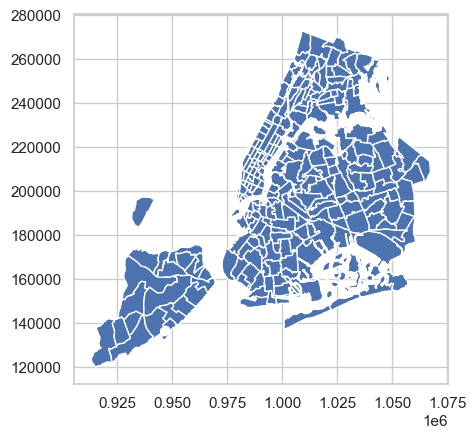

In [43]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [44]:
# Merge zones and trip records using locationID and PULocationID
df_zones = df.merge(zones[["LocationID", "zone", "borough"]], left_on="pulocationid", right_on="LocationID", how="left")
df_zones[["pulocationid", "zone", "borough"]].head()

,pulocationid,zone,borough
0,141,Lenox Hill West,Manhattan
1,138,LaGuardia Airport,Queens
2,161,Midtown Center,Manhattan
3,237,Upper East Side South,Manhattan
4,143,Lincoln Square West,Manhattan


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [45]:
# Group data by location and calculate the number of trips
zone_trip_counts = df.groupby("pulocationid").size().reset_index(name="trip_count")
zone_trip_counts = zone_trip_counts.rename(columns={"pulocationid": "LocationID"})
zone_trip_counts.sort_values("trip_count", ascending=False).head(10)

,LocationID,trip_count
125,132,96828
229,237,88521
154,161,87502
228,236,79704
155,162,66642
131,138,64377
178,186,64245
135,142,62592
222,230,62590
163,170,55876


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [46]:
# Merge trip counts back to the zones GeoDataFrame
zones_with_trips = zones.merge(zone_trip_counts, on="LocationID", how="left")
zones_with_trips["trip_count"] = zones_with_trips["trip_count"].fillna(0).astype(int)
zones_with_trips[["LocationID", "zone", "trip_count"]].head()

,LocationID,zone,trip_count
0,1,Newark Airport,217
1,2,Jamaica Bay,2
2,3,Allerton/Pelham Gardens,44
3,4,Alphabet City,2352
4,5,Arden Heights,13


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

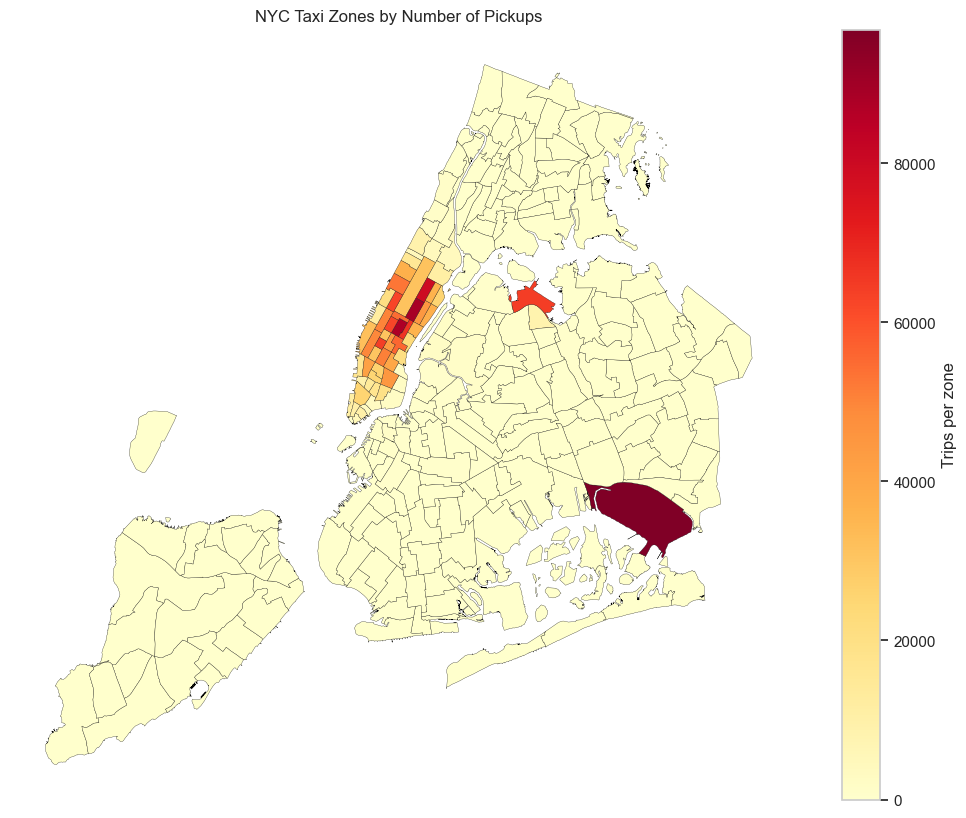

In [47]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Plot the map and display it
zones_with_trips.plot(
    column="trip_count",
    ax=ax,
    legend=True,
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.2,
    legend_kwds={"label": "Trips per zone", "orientation": "vertical"},
)
ax.set_title("NYC Taxi Zones by Number of Pickups")
ax.set_axis_off()
plt.show()

In [48]:
# can you try displaying the zones DF sorted by the number of trips?
zones_with_trips[["zone", "borough", "trip_count"]].sort_values("trip_count", ascending=False).head(20)

,zone,borough,trip_count
131,JFK Airport,Queens,96828
236,Upper East Side South,Manhattan,88521
160,Midtown Center,Manhattan,87502
235,Upper East Side North,Manhattan,79704
161,Midtown East,Manhattan,66642
137,LaGuardia Airport,Queens,64377
185,Penn Station/Madison Sq West,Manhattan,64245
141,Lincoln Square East,Manhattan,62592
229,Times Sq/Theatre District,Manhattan,62590
169,Murray Hill,Manhattan,55876


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [49]:
# Find routes which have the slowest speeds at different times of the day
route_hourly = (
    df_nz.groupby(["pulocationid", "dolocationid", "pickup_hour"])
    .agg(
        trips=("trip_distance", "size"),
        avg_distance=("trip_distance", "mean"),
        avg_duration_min=("trip_duration", "mean"),
    )
    .reset_index()
)

route_hourly = route_hourly[route_hourly["avg_duration_min"] > 0].copy()
route_hourly["avg_speed_mph"] = route_hourly["avg_distance"] / (route_hourly["avg_duration_min"] / 60)

slow_routes = route_hourly[route_hourly["trips"] >= 30].sort_values("avg_speed_mph").head(20)
slow_routes

,pulocationid,dolocationid,pickup_hour,trips,avg_distance,avg_duration_min,avg_speed_mph
91078,186,100,12,78,0.611410,12.735043,2.880604
36682,100,100,16,35,0.556286,11.293333,2.955473
36679,100,100,13,32,0.509375,10.128125,3.017587
91077,186,100,11,70,0.693714,13.305714,3.128194
91079,186,100,13,95,0.637158,11.945088,3.200435
91082,186,100,16,68,0.585000,10.893627,3.222067
91762,186,164,12,81,0.750494,13.851235,3.250947
91084,186,100,18,61,0.614098,10.965847,3.360060
92310,186,230,12,303,1.079703,18.718592,3.460847
36684,100,100,18,39,0.414872,7.167521,3.472931


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

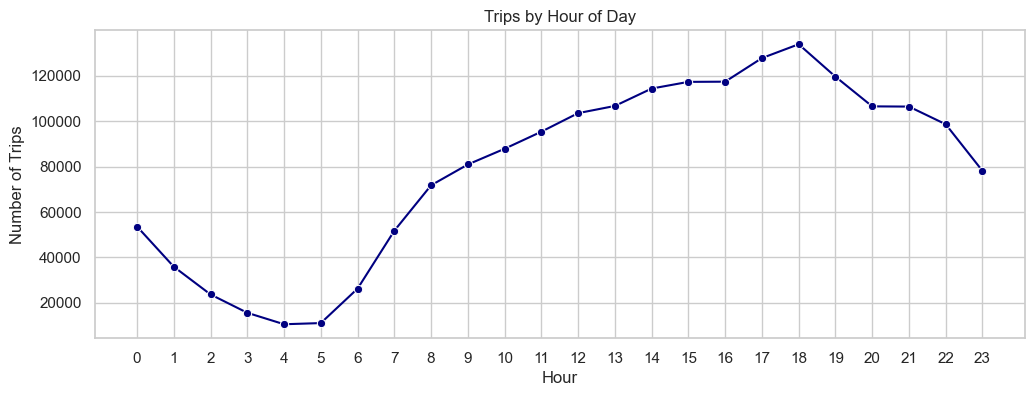

(18, 133781)

In [50]:
# Visualise the number of trips per hour and find the busiest hour
hourly_trips = df.groupby("pickup_hour").size().reindex(range(24), fill_value=0)

plt.figure(figsize=(12, 4))
sns.lineplot(x=hourly_trips.index, y=hourly_trips.values, marker="o", color="navy")
plt.title("Trips by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Trips")
plt.xticks(range(24))
plt.show()

busiest_hour = int(hourly_trips.idxmax())
busiest_count = int(hourly_trips.max())
busiest_hour, busiest_count

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [51]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.05

scaled_hourly_trips = (hourly_trips / sample_fraction).round().astype(int)
scaled_hourly_trips.sort_values(ascending=False).head(5)

pickup_hour
18    2675620
17    2553720
19    2390440
16    2346300
15    2344600
dtype: int32

**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

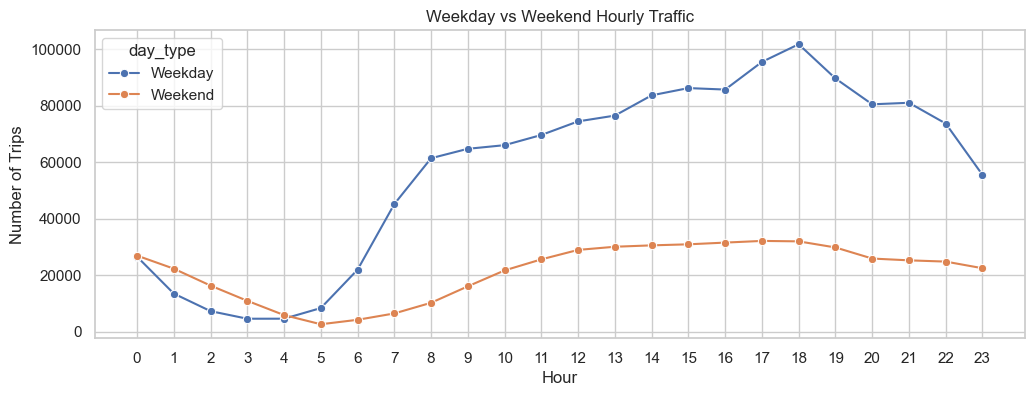

In [52]:
# Compare traffic trends for the week days and weekends
df["is_weekend"] = df["pickup_day"].isin(["Saturday", "Sunday"])
weekday_weekend_hourly = df.groupby(["is_weekend", "pickup_hour"]).size().reset_index(name="trips")
weekday_weekend_hourly["day_type"] = np.where(weekday_weekend_hourly["is_weekend"], "Weekend", "Weekday")

plt.figure(figsize=(12, 4))
sns.lineplot(data=weekday_weekend_hourly, x="pickup_hour", y="trips", hue="day_type", marker="o")
plt.title("Weekday vs Weekend Hourly Traffic")
plt.xlabel("Hour")
plt.ylabel("Number of Trips")
plt.xticks(range(24))
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

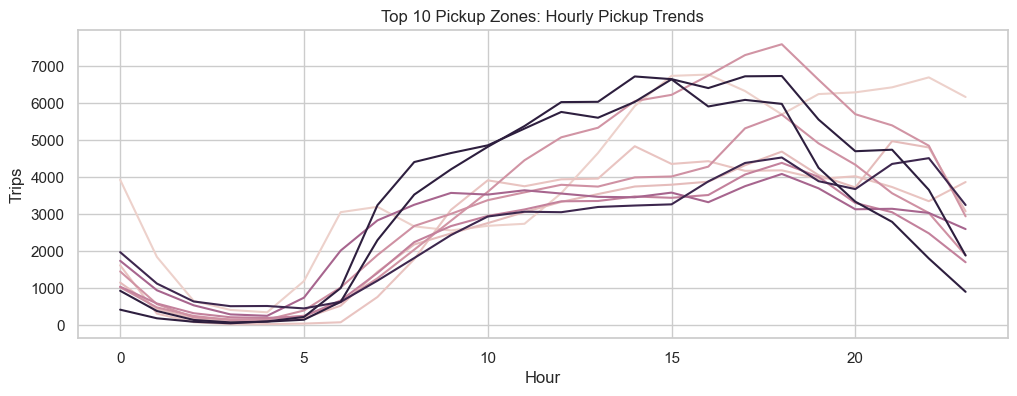

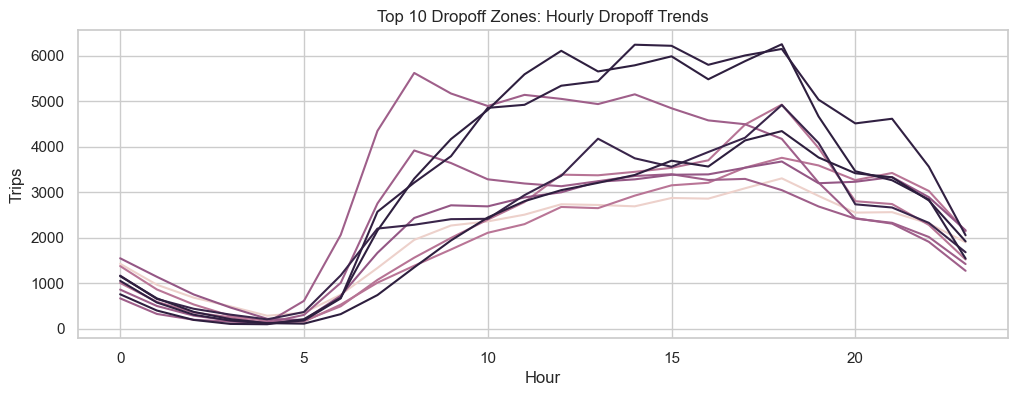

([132, 237, 161, 236, 162, 138, 186, 142, 230, 170],
 [236, 237, 161, 230, 170, 162, 142, 239, 141, 68])

In [53]:
# Find top 10 pickup and dropoff zones
pickup_zone_counts = df.groupby("pulocationid").size().sort_values(ascending=False)
dropoff_zone_counts = df.groupby("dolocationid").size().sort_values(ascending=False)

top10_pickup_zones = pickup_zone_counts.head(10).index.tolist()
top10_dropoff_zones = dropoff_zone_counts.head(10).index.tolist()

pickup_hourly_top = (
    df[df["pulocationid"].isin(top10_pickup_zones)]
    .groupby(["pickup_hour", "pulocationid"])
    .size()
    .reset_index(name="trips")
)

dropoff_hourly_top = (
    df[df["dolocationid"].isin(top10_dropoff_zones)]
    .groupby(["pickup_hour", "dolocationid"])
    .size()
    .reset_index(name="trips")
)

plt.figure(figsize=(12, 4))
sns.lineplot(data=pickup_hourly_top, x="pickup_hour", y="trips", hue="pulocationid", legend=False)
plt.title("Top 10 Pickup Zones: Hourly Pickup Trends")
plt.xlabel("Hour")
plt.ylabel("Trips")
plt.show()

plt.figure(figsize=(12, 4))
sns.lineplot(data=dropoff_hourly_top, x="pickup_hour", y="trips", hue="dolocationid", legend=False)
plt.title("Top 10 Dropoff Zones: Hourly Dropoff Trends")
plt.xlabel("Hour")
plt.ylabel("Trips")
plt.show()

top10_pickup_zones, top10_dropoff_zones

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [54]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
pickup_counts = df.groupby("pulocationid").size().rename("pickup_count")
drop_counts = df.groupby("dolocationid").size().rename("dropoff_count")

zone_flow = pickup_counts.to_frame().merge(drop_counts.to_frame(), left_index=True, right_index=True, how="outer").fillna(0)
zone_flow["pickup_drop_ratio"] = (zone_flow["pickup_count"] + 1) / (zone_flow["dropoff_count"] + 1)

top10_ratio = zone_flow.sort_values("pickup_drop_ratio", ascending=False).head(10)
bottom10_ratio = zone_flow.sort_values("pickup_drop_ratio", ascending=True).head(10)

top10_ratio, bottom10_ratio

(     pickup_count  dropoff_count  pickup_drop_ratio
 70         8379.0         1032.0           8.112294
 132       96828.0        22717.0           4.262215
 199           2.0            0.0           3.000000
 138       64377.0        24554.0           2.621788
 186       64245.0        41276.0           1.556460
 114       25075.0        18230.0           1.375459
 43        31290.0        22858.0           1.368870
 249       41898.0        31459.0           1.331818
 162       66642.0        53677.0           1.241533
 161       87502.0        73674.0           1.187689,
      pickup_count  dropoff_count  pickup_drop_ratio
 1           217.0         5735.0           0.038006
 30            0.0           18.0           0.052632
 257          42.0          796.0           0.053952
 245           1.0           31.0           0.062500
 252          26.0          366.0           0.073569
 27            2.0           39.0           0.075000
 128           8.0          118.0           0

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [55]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones
night_mask = (df["pickup_hour"] >= 23) | (df["pickup_hour"] <= 5)
night_df = df[night_mask].copy()

night_top_pickups = night_df.groupby("pulocationid").size().sort_values(ascending=False).head(10)
night_top_dropoffs = night_df.groupby("dolocationid").size().sort_values(ascending=False).head(10)

night_top_pickups, night_top_dropoffs

(pulocationid
 79     16441
 132    14563
 249    13122
 48     10823
 148    10163
 114     9174
 230     8488
 186     7124
 164     6454
 68      6388
 dtype: int64,
 dolocationid
 79     8705
 48     7211
 170    6497
 68     6123
 107    5941
 141    5540
 263    5269
 249    5123
 230    4843
 148    4619
 dtype: int64)

Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

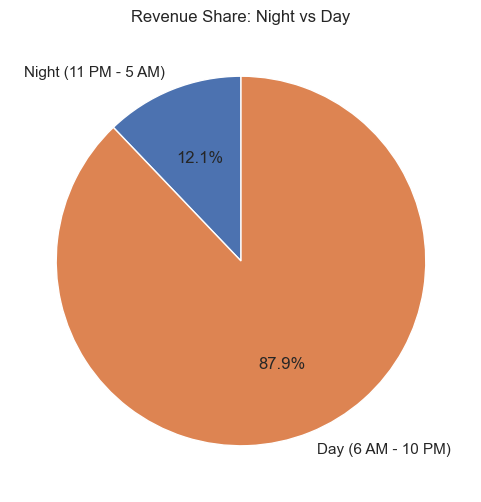

Night (11 PM - 5 AM)     6518072.35
Day (6 AM - 10 PM)      47182751.78
dtype: float64

In [56]:
# Filter for night hours (11 PM to 5 AM)
night_revenue = df_nz.loc[(df_nz["pickup_hour"] >= 23) | (df_nz["pickup_hour"] <= 5), "total_amount"].sum()
day_revenue = df_nz.loc[(df_nz["pickup_hour"] > 5) & (df_nz["pickup_hour"] < 23), "total_amount"].sum()

revenue_share = pd.Series({"Night (11 PM - 5 AM)": night_revenue, "Day (6 AM - 10 PM)": day_revenue})

plt.figure(figsize=(6, 6))
plt.pie(revenue_share.values, labels=list(revenue_share.index), autopct="%1.1f%%", startangle=90)
plt.title("Revenue Share: Night vs Day")
plt.show()

revenue_share

##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

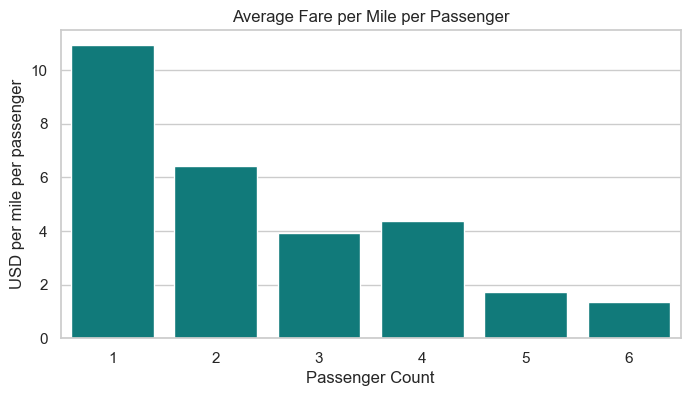

passenger_count
1    10.944894
2     6.427720
3     3.908947
4     4.366345
5     1.710766
6     1.351586
Name: fare_per_mile_per_passenger, dtype: float64

In [57]:
# Analyse the fare per mile per passenger for different passenger counts
df_nz["fare_per_mile_per_passenger"] = df_nz["fare_amount"] / df_nz["trip_distance"] / df_nz["passenger_count"]
fare_per_passenger = df_nz.groupby("passenger_count")["fare_per_mile_per_passenger"].mean().sort_index()

plt.figure(figsize=(8, 4))
sns.barplot(x=fare_per_passenger.index, y=fare_per_passenger.values, color="darkcyan")
plt.title("Average Fare per Mile per Passenger")
plt.xlabel("Passenger Count")
plt.ylabel("USD per mile per passenger")
plt.show()

fare_per_passenger

**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

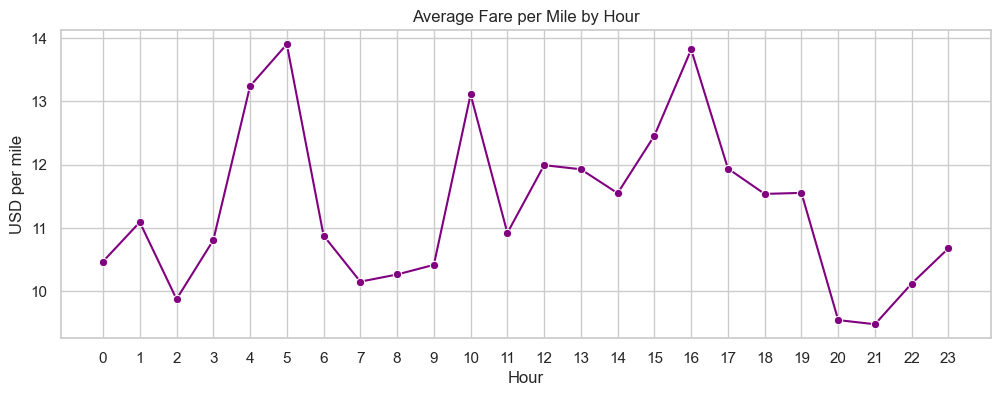

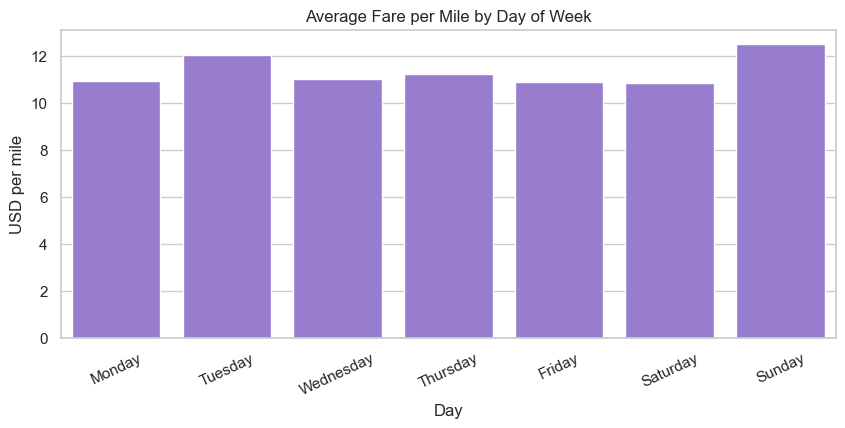

(pickup_hour
 0    10.472547
 1    11.093450
 2     9.878921
 3    10.809183
 4    13.240792
 Name: fare_per_mile, dtype: float64,
 pickup_day
 Monday       10.919153
 Tuesday      12.059795
 Wednesday    11.028605
 Thursday     11.224197
 Friday       10.877178
 Saturday     10.858604
 Sunday       12.504290
 Name: fare_per_mile, dtype: float64)

In [58]:
# Compare the average fare per mile for different days and for different times of the day
df_nz["fare_per_mile"] = df_nz["fare_amount"] / df_nz["trip_distance"]

fare_by_hour = df_nz.groupby("pickup_hour")["fare_per_mile"].mean()
fare_by_day = df_nz.groupby("pickup_day")["fare_per_mile"].mean().reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])

plt.figure(figsize=(12, 4))
sns.lineplot(x=fare_by_hour.index, y=fare_by_hour.values, marker="o", color="purple")
plt.title("Average Fare per Mile by Hour")
plt.xlabel("Hour")
plt.ylabel("USD per mile")
plt.xticks(range(24))
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(x=fare_by_day.index, y=fare_by_day.values, color="mediumpurple")
plt.title("Average Fare per Mile by Day of Week")
plt.xlabel("Day")
plt.ylabel("USD per mile")
plt.xticks(rotation=25)
plt.show()

fare_by_hour.head(), fare_by_day

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

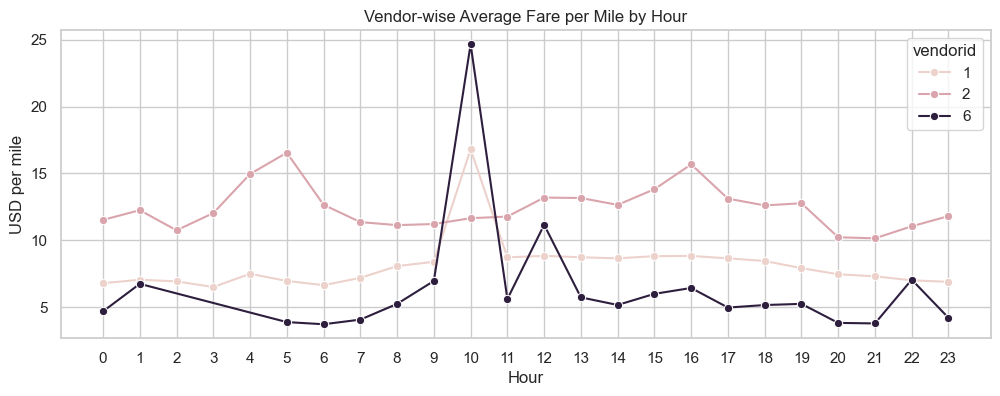

,vendorid,pickup_hour,fare_per_mile
0,1,0,6.795392
1,1,1,7.055755
2,1,2,6.932000
3,1,3,6.510311
4,1,4,7.498874


In [59]:
# Compare fare per mile for different vendors
vendor_hourly_fare = (
    df_nz.groupby(["vendorid", "pickup_hour"])["fare_per_mile"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 4))
sns.lineplot(data=vendor_hourly_fare, x="pickup_hour", y="fare_per_mile", hue="vendorid", marker="o")
plt.title("Vendor-wise Average Fare per Mile by Hour")
plt.xlabel("Hour")
plt.ylabel("USD per mile")
plt.xticks(range(24))
plt.show()

vendor_hourly_fare.head()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


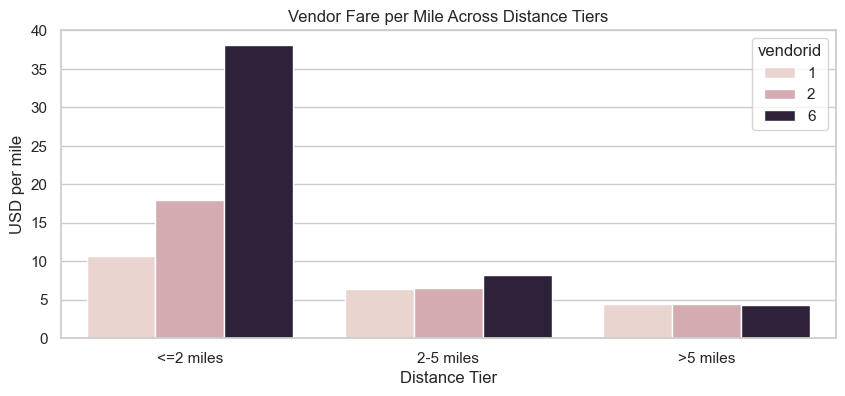

,vendorid,distance_tier,fare_per_mile
0,1,<=2 miles,10.638311
1,1,2-5 miles,6.382494
2,1,>5 miles,4.426863
3,2,<=2 miles,17.968883
4,2,2-5 miles,6.538117
5,2,>5 miles,4.489769
6,6,<=2 miles,38.122035
7,6,2-5 miles,8.231847
8,6,>5 miles,4.353329


In [60]:
# Defining distance tiers
df_nz["distance_tier"] = pd.cut(
    df_nz["trip_distance"],
    bins=[0, 2, 5, np.inf],
    labels=["<=2 miles", "2-5 miles", ">5 miles"],
    include_lowest=True,
)

vendor_tier_fare = (
    df_nz.groupby(["vendorid", "distance_tier"], observed=True)["fare_per_mile"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 4))
sns.barplot(data=vendor_tier_fare, x="distance_tier", y="fare_per_mile", hue="vendorid")
plt.title("Vendor Fare per Mile Across Distance Tiers")
plt.xlabel("Distance Tier")
plt.ylabel("USD per mile")
plt.show()

vendor_tier_fare

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

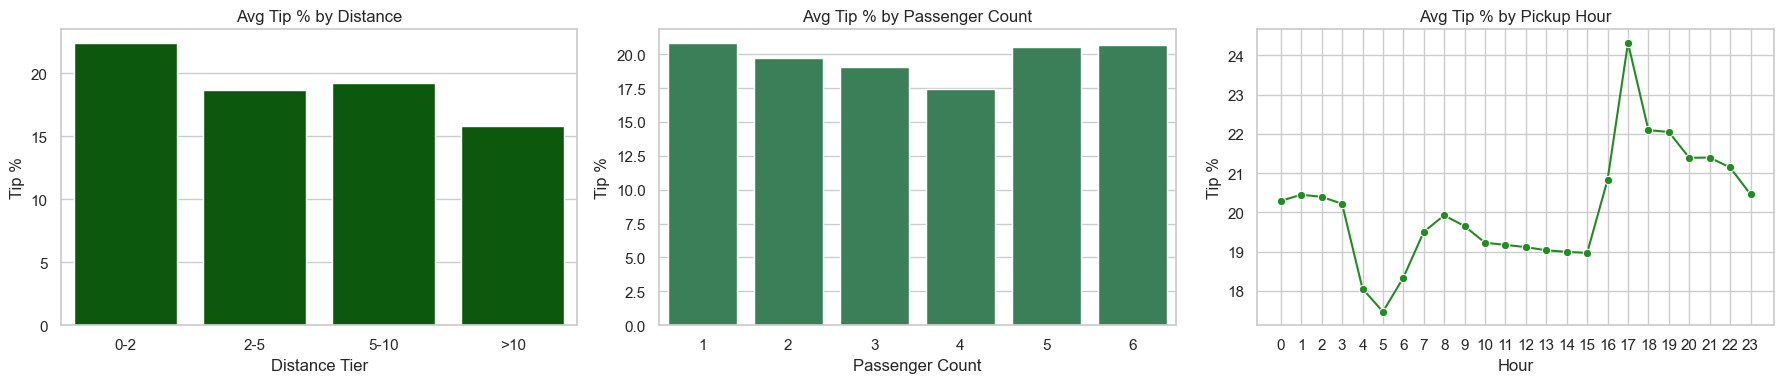

(tip_distance_tier
 0-2     22.371839
 2-5     18.639509
 5-10    19.252155
 >10     15.821406
 Name: tip_pct, dtype: float64,
 passenger_count
 1    20.788266
 2    19.736446
 3    19.032419
 4    17.461013
 5    20.531744
 Name: tip_pct, dtype: float64)

In [61]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
df_nz["tip_pct"] = np.where(df_nz["fare_amount"] > 0, (df_nz["tip_amount"] / df_nz["fare_amount"]) * 100, 0)

df_nz["tip_distance_tier"] = pd.cut(
    df_nz["trip_distance"],
    bins=[0, 2, 5, 10, np.inf],
    labels=["0-2", "2-5", "5-10", ">10"],
    include_lowest=True,
)

tip_by_distance = df_nz.groupby("tip_distance_tier", observed=True)["tip_pct"].mean()
tip_by_passenger = df_nz.groupby("passenger_count")["tip_pct"].mean()
tip_by_hour = df_nz.groupby("pickup_hour")["tip_pct"].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.barplot(x=tip_by_distance.index, y=tip_by_distance.values, ax=axes[0], color="darkgreen")
axes[0].set_title("Avg Tip % by Distance")
axes[0].set_xlabel("Distance Tier")
axes[0].set_ylabel("Tip %")

sns.barplot(x=tip_by_passenger.index, y=tip_by_passenger.values, ax=axes[1], color="seagreen")
axes[1].set_title("Avg Tip % by Passenger Count")
axes[1].set_xlabel("Passenger Count")
axes[1].set_ylabel("Tip %")

sns.lineplot(x=tip_by_hour.index, y=tip_by_hour.values, marker="o", ax=axes[2], color="forestgreen")
axes[2].set_title("Avg Tip % by Pickup Hour")
axes[2].set_xlabel("Hour")
axes[2].set_ylabel("Tip %")
axes[2].set_xticks(range(24))

plt.tight_layout()
plt.show()

tip_by_distance, tip_by_passenger.head()

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [63]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
low_tip = df_nz[df_nz["tip_pct"] < 10]
high_tip = df_nz[df_nz["tip_pct"] > 25]

tip_compare = pd.DataFrame({
    "metric": ["avg_trip_distance", "avg_fare_amount", "avg_passenger_count", "credit_card_share"],
    "low_tip_group": [
        low_tip["trip_distance"].mean(),
        low_tip["fare_amount"].mean(),
        low_tip["passenger_count"].mean(),
        (low_tip["payment_type"] == 1).mean(),
    ],
    "high_tip_group": [
        high_tip["trip_distance"].mean(),
        high_tip["fare_amount"].mean(),
        high_tip["passenger_count"].mean(),
        (high_tip["payment_type"] == 1).mean(),
    ],
})

tip_compare

,metric,low_tip_group,high_tip_group
0,avg_trip_distance,3.934600,2.310342
1,avg_fare_amount,21.940951,14.438940
2,avg_passenger_count,1.416863,1.358600
3,credit_card_share,0.322749,0.999964


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

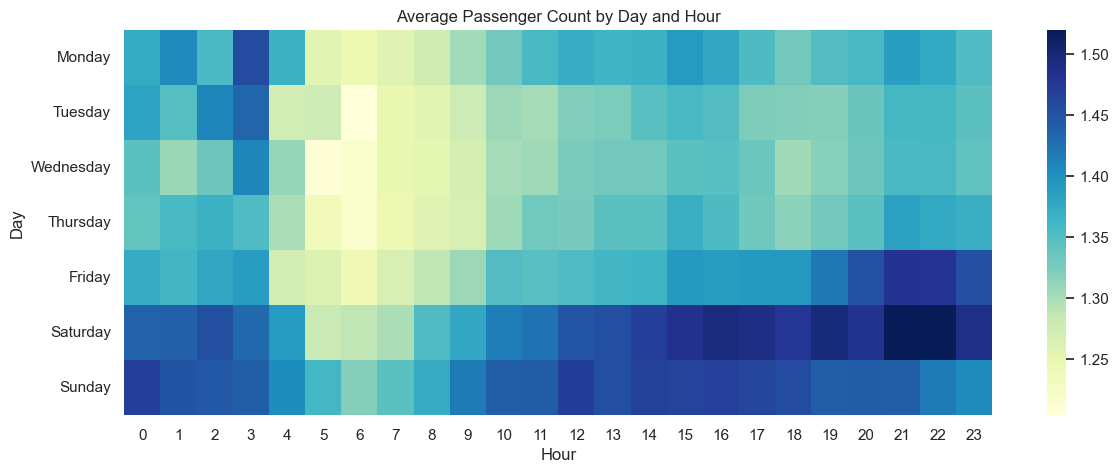

,pickup_day,pickup_hour,passenger_count
0,Friday,0,1.373634
1,Friday,1,1.361205
2,Friday,2,1.378160
3,Friday,3,1.388684
4,Friday,4,1.273138


In [64]:
# See how passenger count varies across hours and days
hour_day_passenger = (
    df.groupby(["pickup_day", "pickup_hour"])["passenger_count"]
    .mean()
    .reset_index()
)

hour_day_pivot = hour_day_passenger.pivot(index="pickup_day", columns="pickup_hour", values="passenger_count")
hour_day_pivot = hour_day_pivot.reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])

plt.figure(figsize=(14, 5))
sns.heatmap(hour_day_pivot, cmap="YlGnBu")
plt.title("Average Passenger Count by Day and Hour")
plt.xlabel("Hour")
plt.ylabel("Day")
plt.show()

hour_day_passenger.head()

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [65]:
# How does passenger count vary across zones
zone_passenger = (
    df.groupby("pulocationid")["passenger_count"]
    .mean()
    .sort_values(ascending=False)
    .reset_index(name="avg_passenger_count")
)
zone_passenger.head(20)

,pulocationid,avg_passenger_count
0,6,1.840000
1,204,1.800000
2,12,1.727599
3,195,1.700000
4,1,1.594470
5,178,1.533333
6,261,1.524503
7,93,1.524173
8,58,1.500000
9,59,1.500000


In [66]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.
zones_with_trips = zones_with_trips.merge(
    zone_passenger.rename(columns={"pulocationid": "LocationID"}),
    on="LocationID",
    how="left",
)
zones_with_trips[["LocationID", "zone", "trip_count", "avg_passenger_count"]].head()

,LocationID,zone,trip_count,avg_passenger_count
0,1,Newark Airport,217,1.594470
1,2,Jamaica Bay,2,1.000000
2,3,Allerton/Pelham Gardens,44,1.022727
3,4,Alphabet City,2352,1.340561
4,5,Arden Heights,13,1.000000


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

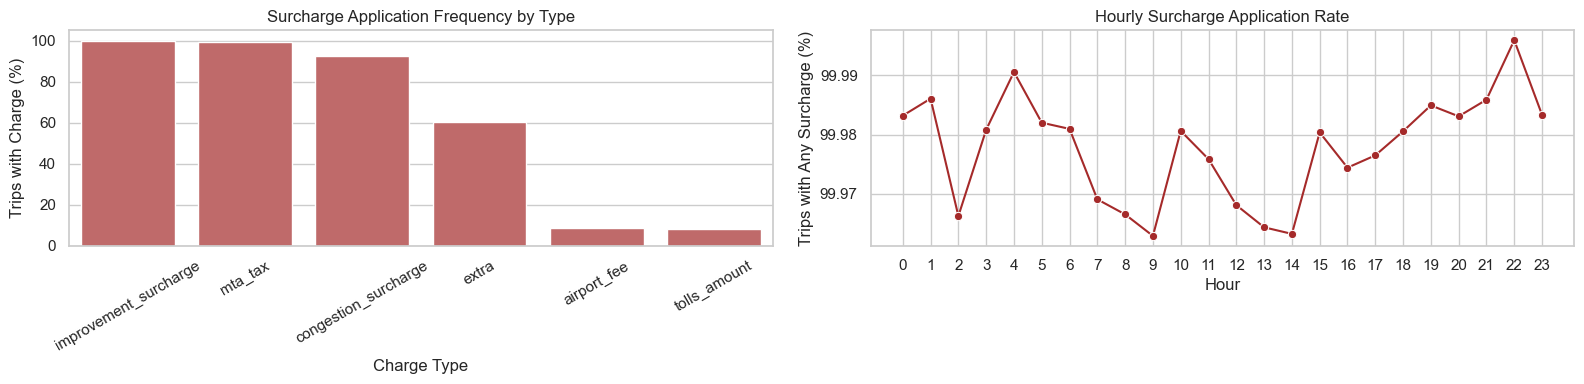

(improvement_surcharge    99.960767
 mta_tax                  99.072664
 congestion_surcharge     92.587649
 extra                    60.099419
 airport_fee               8.484475
 tolls_amount              8.108144
 dtype: float64,
 pulocationid
 1      100.0
 235    100.0
 127    100.0
 128    100.0
 129    100.0
 131    100.0
 133    100.0
 242    100.0
 2      100.0
 139    100.0
 Name: any_surcharge, dtype: float64)

In [67]:
# How often is each surcharge applied?
surcharge_cols = ["extra", "mta_tax", "improvement_surcharge", "congestion_surcharge", "airport_fee", "tolls_amount"]

surcharge_applied = (df[surcharge_cols] > 0).mean().sort_values(ascending=False) * 100

df["any_surcharge"] = (df[surcharge_cols].sum(axis=1) > 0).astype(int)

hourly_surcharge_rate = df.groupby("pickup_hour")["any_surcharge"].mean() * 100
zone_surcharge_rate = df.groupby("pulocationid")["any_surcharge"].mean().sort_values(ascending=False).head(10) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.barplot(x=surcharge_applied.index, y=surcharge_applied.values, ax=axes[0], color="indianred")
axes[0].set_title("Surcharge Application Frequency by Type")
axes[0].set_xlabel("Charge Type")
axes[0].set_ylabel("Trips with Charge (%)")
axes[0].tick_params(axis="x", rotation=30)

sns.lineplot(x=hourly_surcharge_rate.index, y=hourly_surcharge_rate.values, marker="o", ax=axes[1], color="brown")
axes[1].set_title("Hourly Surcharge Application Rate")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Trips with Any Surcharge (%)")
axes[1].set_xticks(range(24))

plt.tight_layout()
plt.show()

surcharge_applied, zone_surcharge_rate

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

**Routing and Dispatching Recommendations**

1. **Pre-position cabs 30-60 minutes before demand peaks.**
   The hourly trip curve (3.1.2, 3.2.2) shows a sharp evening peak around **17:00-19:00** on weekdays and a secondary morning peak around **08:00-09:00**. Dispatching idle cabs toward top pickup zones just before these windows reduces passenger wait time and captures peak fares.

2. **Actively avoid the slowest route-hour combinations.**
   Slow-route analysis (3.2.1) identifies specific PU-DO pairs where average speed drops below ~8 mph during evening rush hours. Route these pairs through alternative corridors during those hours to protect driver earnings per hour and improve on-time drop-off.

3. **Rebalance supply using the pickup-to-dropoff ratio (3.2.6).**
   Zones with ratio well above 1 (net exporters, e.g. Midtown, JFK/LGA) release more cabs than they absorb, while ratio below 1 (net importers, e.g. residential outer zones) accumulate idle cabs. Schedule short repositioning trips from importer to exporter zones during off-peak intervals.

4. **Boost weekend late-night dispatch.**
   The weekday vs weekend comparison (3.2.4) shows weekend traffic shifts later, with a Fri-Sat **23:00-02:00** spike that weekday patterns do not have. Maintain an extra shift block on Fri and Sat nights covering entertainment-district pickup zones (3.2.7).

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

**Cab Positioning Recommendations**

1. **Concentrate the day-shift fleet in the top 10 pickup zones.**
   Zonal analysis (3.1.11, 3.1.13, 3.2.5) shows Manhattan CBD zones (Midtown Center, Upper East/West, Times Sq/Theater District, Penn Station) plus JFK and LaGuardia dominate total pickups. Allocate cabs across these zones proportional to their trip share.

2. **Redistribute cabs at night to the night-hotspot zones.**
   Night-hour analysis (3.2.7) shows a different set of dominant pickup zones after 23:00 — typically nightlife/entertainment districts (East Village, LES, Meatpacking) plus airports. Move a subset of the fleet toward these zones at ~22:00 so they are in position by 23:00.

3. **Position cabs based on zone-level passenger-volume signals.**
   Zone passenger-count means (3.2.15) show that a small number of zones consistently carry larger groups (airports, terminals, event venues). Route higher-capacity vehicles to those zones.

4. **Use pickup/dropoff imbalance to schedule empty-return routes.**
   The lowest ratios (3.2.6) are zones that receive many drop-offs but generate few pickups (e.g. late-night residential drop-offs). Send idle drivers in those zones on short return trips toward the nearest exporter zone rather than waiting.

5. **Publish separate allocation plans for weekdays and weekends.**
   Weekday demand is business-heavy (CBD, transit hubs), while weekend demand skews to residential-to-entertainment flows (3.2.4). Two zone allocation plans — one for Mon-Fri and one for Sat-Sun — better match supply to demand.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

**Pricing Strategy Recommendations**

1. **Apply distance-tiered per-mile pricing.**
   Distance-tier comparison (3.2.12) shows fare per mile is highest on short trips (≤2 mi) and drops steeply on trips >5 mi. Introduce a mild long-trip premium (or reduced discount) on >5 mi trips to align revenue capture with vendor benchmarks.

2. **Enable time-of-day surge pricing during low-speed peak windows.**
   Fare per mile by hour (3.2.10) is elevated during evening rush and early morning, coinciding with slow-route hours (3.2.1). A modest surge multiplier during **17:00-19:00** on top demand zones offsets throughput lost to congestion.

3. **Charge a distinct night-hour rate.**
   Night vs day revenue share (3.2.8) shows nighttime carries disproportionate revenue per trip — driven by longer average distances (airports) and higher surcharge acceptance. Formalize a night surcharge on trips from **23:00-05:00** in top night-hotspot zones (3.2.7).

4. **Match vendor pricing tier-by-tier instead of a single flat rate.**
   Vendor comparison (3.2.11, 3.2.12) shows differences across distance tiers — one vendor is cheaper on short trips, the other on long trips. Adopt a tiered rate card that beats the cheaper vendor by ~2-3% in each tier to remain competitive.

5. **Nudge passengers toward card payments to lift tips.**
   Tip analysis (3.2.13) and the low-vs-high tip comparison show credit-card trips have materially higher tip percentages than cash. Reduce card-swipe friction in the vehicle app and pre-select suggested tip amounts on the payment screen.

6. **Bundle surcharges transparently on the receipt.**
   Surcharge frequency analysis (3.2.16) shows congestion surcharge, MTA tax, and improvement surcharge apply on the vast majority of trips. Show a single "city fees" line item on the receipt to reduce dispute rate (`payment_type = 4`).

7. **Offer a small volume discount on 1-passenger short trips.**
   Fare per mile per passenger (3.2.9) is highest for 1-passenger short-distance trips. A modest discount here can grow trip count without materially reducing per-trip revenue.